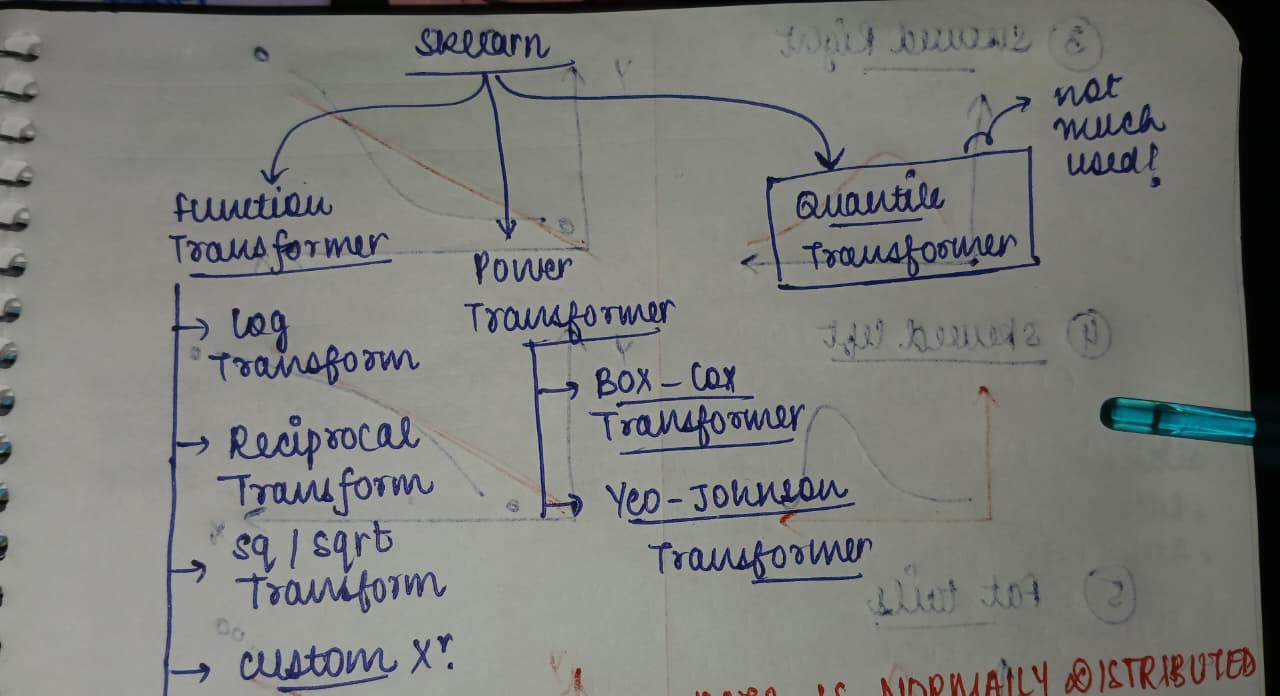

Function Transformer->
only using `age`, `fare` ,`survived` columns of `titanic` dataset

In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats # will use this to plot Q-Q plot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [ ]:
df = pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [ ]:
x= df.iloc[:,1:3]
x

y=df.iloc[:,0]
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_802/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [ ]:
df['Age'].isnull().sum()

np.int64(0)

### Train_test_split

In [ ]:
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

/tmp/ipykernel_802/185814349.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


Text(0.5, 1.0, 'Age QQ Plot')

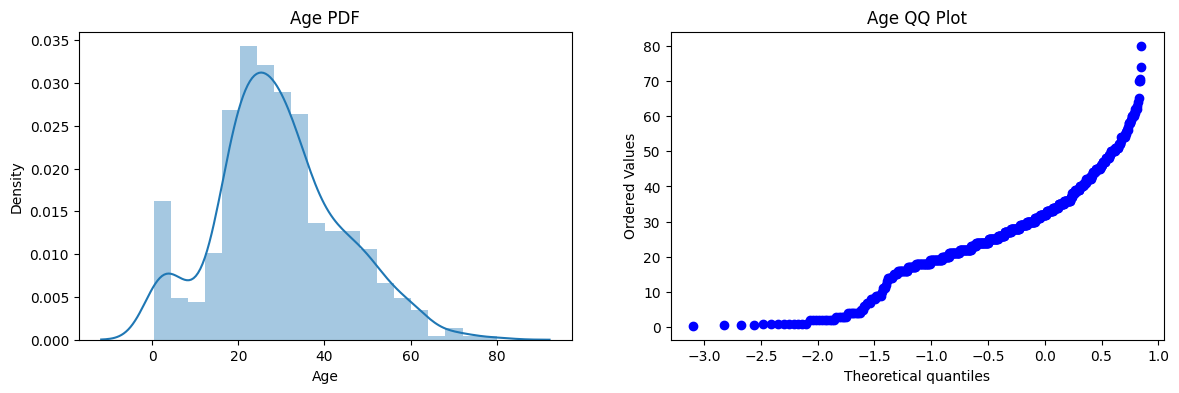

In [ ]:
#observing 'Age' column
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title("Age PDF")
#q-q plot
plt.subplot(122)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title("Age QQ Plot")

/tmp/ipykernel_802/1417364968.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


Text(0.5, 1.0, 'Age QQ Plot')

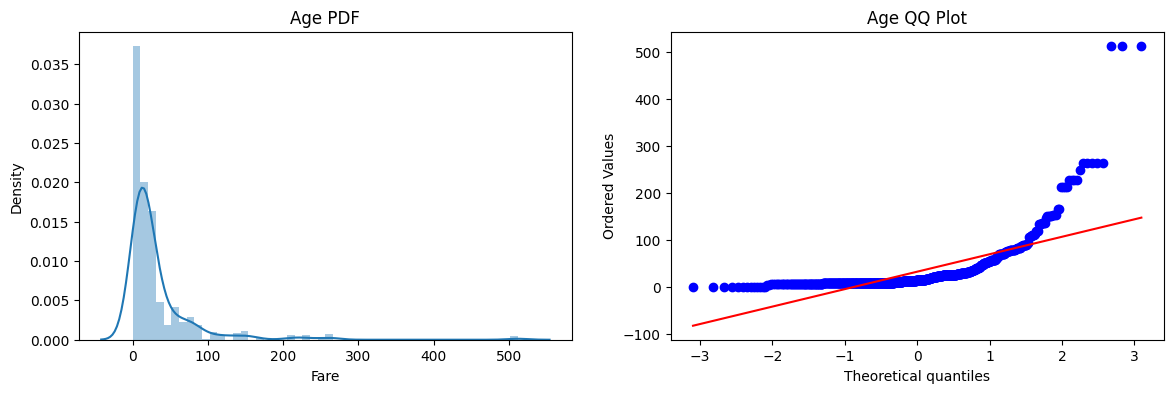

In [ ]:
# observing 'fare' column
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title("Age PDF")
 #q-q plot
plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title("Age QQ Plot")

In [ ]:
clf = LogisticRegression()
clf2= DecisionTreeClassifier()

## Without Transformations:
the accuracy score is quite low.

In [ ]:
from sklearn.impute import SimpleImputer

# Create an imputer that replaces missing values with the mean
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on x_train and transform both x_train and x_test
x_train_imputed = imputer.fit_transform(x_train)
x_test_imputed = imputer.transform(x_test)

clf.fit(x_train_imputed, y_train)
clf2.fit(x_train_imputed, y_train)

y_pred = clf.predict(x_test_imputed)
y_pred2 = clf2.predict(x_test_imputed)

print("Accuracy score LR:",accuracy_score(y_test,y_pred))
print("Accuracy score LR:",accuracy_score(y_test,y_pred2))

Accuracy score LR: 0.6480446927374302
Accuracy score LR: 0.664804469273743


## Applying Transformations:

accuracy improves for logistic regression model, not for decisionTreeClassifier



#### Difference between np.log and np.log1p
>`np.log`-> doesnt get anything on log(0)

>`np.log1p`-> adds 1 if input is 0 that's why code doesnt crashes out.

In [ ]:
trf = FunctionTransformer( func= np.log1p)

In [ ]:
x_train_transformed = trf.fit_transform(x_train_imputed)
x_test_transformed = trf.transform(x_test_imputed)

In [ ]:
clf= LogisticRegression()
clf2= DecisionTreeClassifier()

clf.fit(x_train_transformed, y_train)
clf2.fit(x_train_transformed, y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print("Accuracy score LR:",accuracy_score(y_test,y_pred))
print("Accuracy score DT:",accuracy_score(y_test,y_pred2)) #decision tree algo doesn't
# care how the distribution looks like that's why accuracy score downgrades

Accuracy score LR: 0.6815642458100558
Accuracy score DT: 0.6703910614525139


### We can't really say that regression-model has improved we need t0 cross-validate things

Cross-validate: doing train_test_split for 10 times and finally claculating mean of each time. this gets more fine accuracy score.

In [ ]:

clf= LogisticRegression()
clf2= DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,x_train_transformed,y_train,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,x_train_transformed,y_train,scoring='accuracy',cv=10)))

LR 0.6783646322378717
DT 0.6165101721439751


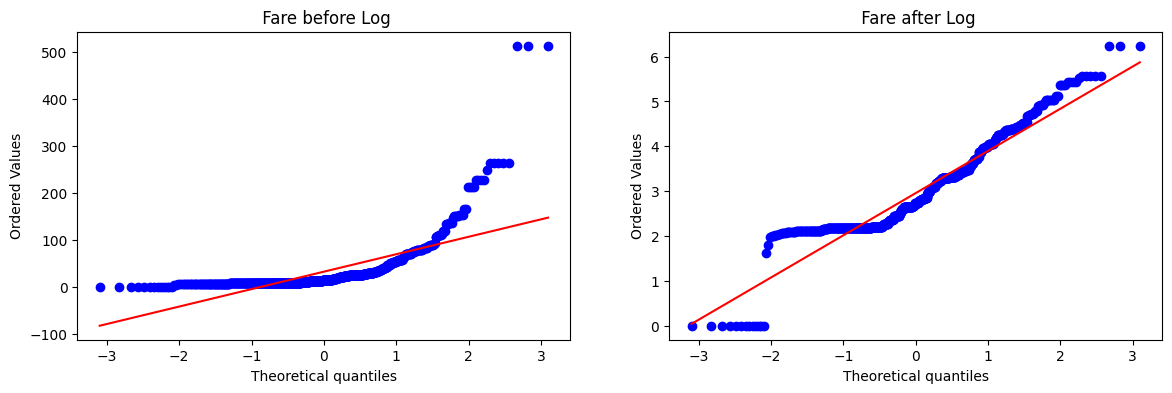

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'],dist= "norm",plot=plt)
plt.title(" Fare before Log")

plt.subplot(122)
stats.probplot(x_train_transformed[:, 1],dist= "norm",plot=plt) # Corrected indexing for NumPy array
plt.title(" Fare after Log")

plt.show()

In [ ]:
#this clearly shows that before applyling transformations the dataset was far away from normal distribution
# whereas, after looking at the Q-Q plot after transformations the datset is very much close to normal distribution.

> Other Transformers

* reciprocal (1/x)
* sqrt**1/2
* square(**2)

In [ ]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()


Accuracy 0.61729088639201


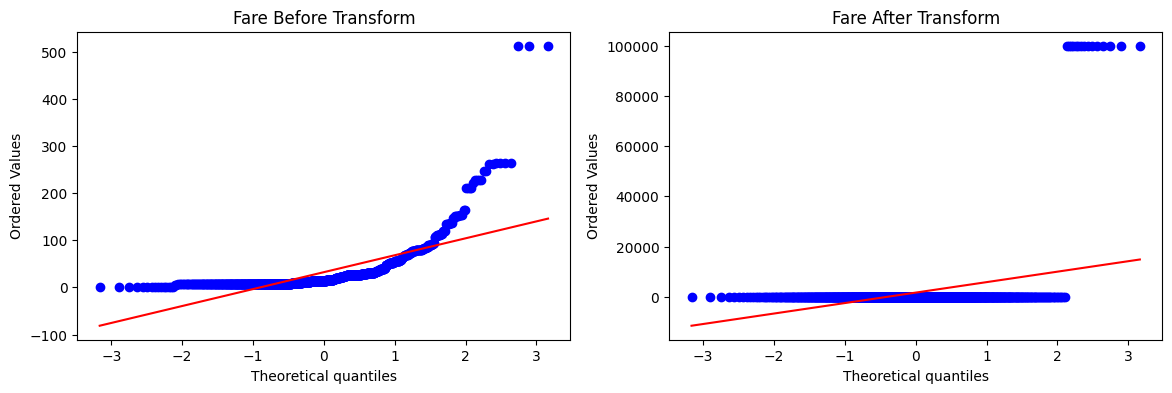

In [ ]:
apply_transform(lambda x: 1/(x+0.00001))